# Machine Learning Evaluation and Information Theory Playground
This notebook focuses on **manual calculation** and **visualization** of core machine learning evaluation metrics and cross-validation techniques.
We avoid using `sklearn.metrics` for the calculations themselves to build strong intuition.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.linear_model import LinearRegression

# Global visual settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)


---
## 1. Classification Metrics (Manual Implementation)
We will implement Accuracy, Precision, Recall, and F1-score manually. 
To do this, we first need to build a Confusion Matrix.


In [3]:
def manual_confusion_matrix(y_true, y_pred, classes):
    '''
    Calculates a confusion matrix manually.
    y_true: True labels
    y_pred: Predicted labels
    classes: List of unique classes
    '''
    n_classes = len(classes)
    matrix = np.zeros((n_classes, n_classes), dtype=int)
    
    class_to_idx = {c: i for i, c in enumerate(classes)}
    
    for true_lbl, pred_lbl in zip(y_true, y_pred):
        matrix[class_to_idx[true_lbl], class_to_idx[pred_lbl]] += 1
        
    return matrix

def plot_confusion_matrix(matrix, classes):
    plt.figure(figsize=(6, 5))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()


Let's create some dummy binary classification data to test our metrics.


Confusion Matrix:
[[4 1]
 [2 3]]


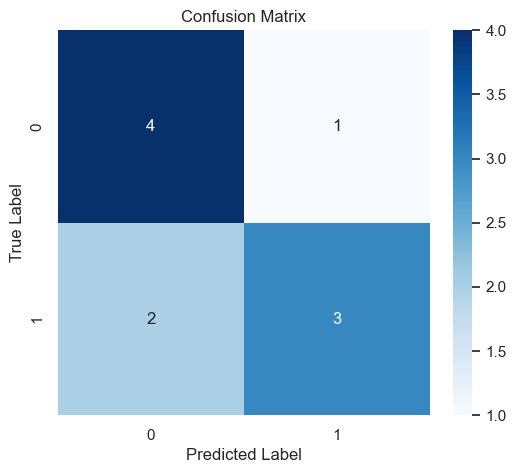

In [4]:
# 0 = Negative (e.g., Healthy), 1 = Positive (e.g., Sick)
y_true_binary = [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]
y_pred_binary = [0, 0, 0, 0, 1, 1, 1, 1, 0, 0] 

classes_binary = [0, 1]
cm_binary = manual_confusion_matrix(y_true_binary, y_pred_binary, classes_binary)

print("Confusion Matrix:")
print(cm_binary)
plot_confusion_matrix(cm_binary, classes_binary)


In [5]:
def manual_binary_metrics(cm):
    '''
    cm: 2x2 confusion matrix
    [0,0] = TN, [0,1] = FP
    [1,0] = FN, [1,1] = TP
    '''
    TN, FP = cm[0, 0], cm[0, 1]
    FN, TP = cm[1, 0], cm[1, 1]
    
    print(f"True Positives (TP): {TP}")
    print(f"True Negatives (TN): {TN}")
    print(f"False Positives (FP): {FP} (Type I Error)")
    print(f"False Negatives (FN): {FN} (Type II Error)\n")
    
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0 # Also known as Sensitivity
    
    if precision + recall > 0:
        f1_score = 2 * (precision * recall) / (precision + recall)
    else:
        f1_score = 0
        
    return accuracy, precision, recall, f1_score

acc, prec, rec, f1 = manual_binary_metrics(cm_binary)
print(f"Accuracy:  {acc:.2f}")
print(f"Precision: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")


True Positives (TP): 3
True Negatives (TN): 4
False Positives (FP): 1 (Type I Error)
False Negatives (FN): 2 (Type II Error)

Accuracy:  0.70
Precision: 0.75
Recall:    0.60
F1-Score:  0.67


---
## 2. Regression Metrics ($R^2$, F-statistic, p-value)

Let's calculate $R^2$ manually.


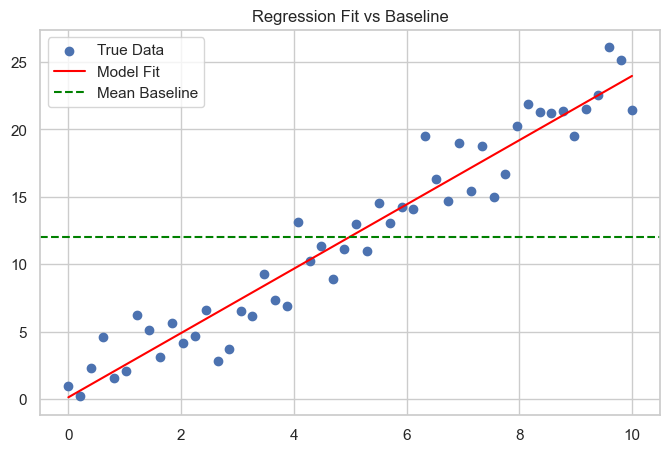

SS_fit (Model Error): 165.03
SS_mean (Baseline Error): 2629.86

Calculated R^2: 0.9372


In [6]:
def manual_r2(y_true, y_pred):
    y_mean = np.mean(y_true)
    
    # Sum of squared errors for the model fit
    ss_fit = np.sum((y_true - y_pred)**2)
    
    # Sum of squared errors for a baseline mean prediction
    ss_mean = np.sum((y_true - y_mean)**2)
    
    r2 = 1 - (ss_fit / ss_mean)
    
    print(f"SS_fit (Model Error): {ss_fit:.2f}")
    print(f"SS_mean (Baseline Error): {ss_mean:.2f}")
    
    return r2

# Dummy Regression Data
np.random.seed(42)
X_dummy = np.linspace(0, 10, 50)
y_true_reg = 2.5 * X_dummy + np.random.normal(0, 2, 50) # True relationship + noise

# Let's fit a simple Linear Regression just to get predictions
model = LinearRegression().fit(X_dummy.reshape(-1, 1), y_true_reg)
y_pred_reg = model.predict(X_dummy.reshape(-1, 1))

plt.scatter(X_dummy, y_true_reg, label='True Data')
plt.plot(X_dummy, y_pred_reg, color='red', label='Model Fit')
plt.axhline(np.mean(y_true_reg), color='green', linestyle='--', label='Mean Baseline')
plt.legend()
plt.title('Regression Fit vs Baseline')
plt.show()

r2_val = manual_r2(y_true_reg, y_pred_reg)
print(f"\nCalculated R^2: {r2_val:.4f}")


### F-Statistic and p-value manually


In [7]:
def manual_f_statistic(y_true, y_pred, p_fit):
    n = len(y_true)
    p_mean = 1 # baseline model has 1 parameter (the mean)
    
    y_mean = np.mean(y_true)
    ss_fit = np.sum((y_true - y_pred)**2)
    ss_mean = np.sum((y_true - y_mean)**2)
    
    # Variation explained by the model
    variation_explained = ss_mean - ss_fit
    degrees_of_freedom_explained = p_fit - p_mean
    
    # Variation NOT explained by the model (Residuals)
    variation_not_explained = ss_fit
    degrees_of_freedom_not_explained = n - p_fit
    
    f_stat = (variation_explained / degrees_of_freedom_explained) / (variation_not_explained / degrees_of_freedom_not_explained)
    return f_stat

f_val = manual_f_statistic(y_true_reg, y_pred_reg, p_fit=2) # p_fit=2 because 1 feature + 1 intercept
print(f"F-Statistic: {f_val:.4f}")


F-Statistic: 716.9190


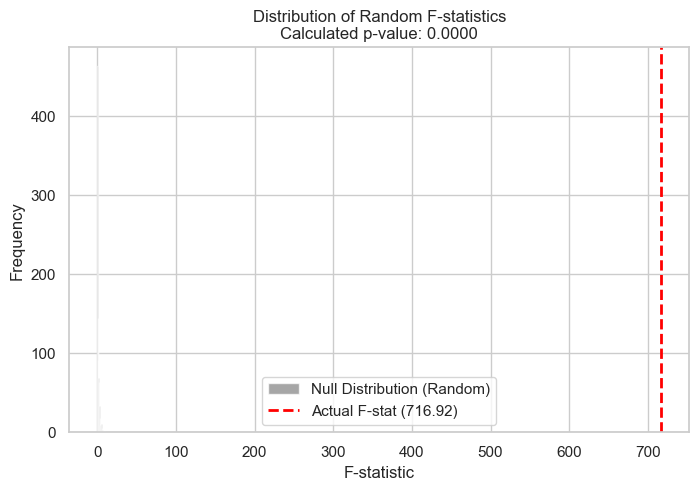

In [11]:
def calculate_p_value_permutation(X, y, actual_f_stat, n_permutations=1000):
    '''
    Calculates p-value by randomly shuffling the target variable y.
    This destroys the relationship between X and y.
    We see how often a random relationship produces an F-statistic >= our actual one.
    '''
    random_f_stats = []
    
    for _ in range(n_permutations):
        # Shuffle y
        y_shuffled = np.random.permutation(y)
        
        # Fit model on random data
        mod = LinearRegression().fit(X.reshape(-1, 1), y_shuffled)
        y_pred_rand = mod.predict(X.reshape(-1, 1))
        
        # Calculate F-stat for random data
        f_rand = manual_f_statistic(y_shuffled, y_pred_rand, p_fit=2)
        random_f_stats.append(f_rand)
        
    random_f_stats = np.array(random_f_stats)
    p_value = np.sum(random_f_stats >= actual_f_stat) / n_permutations
    
    # Plotting the distribution of Random F-statistics
    plt.hist(random_f_stats, bins=30, alpha=0.7, color='grey', label='Null Distribution (Random)')
    plt.axvline(actual_f_stat, color='red', linestyle='dashed', linewidth=2, label=f'Actual F-stat ({actual_f_stat:.2f})')
    plt.title(f'Distribution of Random F-statistics\nCalculated p-value: {p_value:.4f}')
    plt.xlabel('F-statistic')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()
    
    return p_value

p_val = calculate_p_value_permutation(X_dummy, y_true_reg, f_val, n_permutations=1000)


---
## 3. Cross-Validation: K-Fold vs Stratified K-Fold
Let's visualize why Stratified K-Fold is essential for imbalanced datasets.


Notice how Standard K-Fold might have folds with ZERO Class 1 samples (Red).


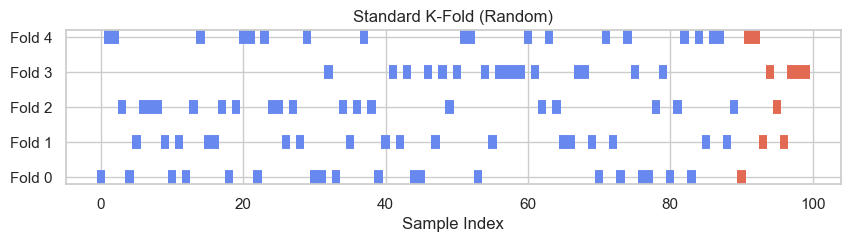

Notice how Stratified K-Fold ensures exactly 2 Class 1 samples (Red) in EVERY fold.


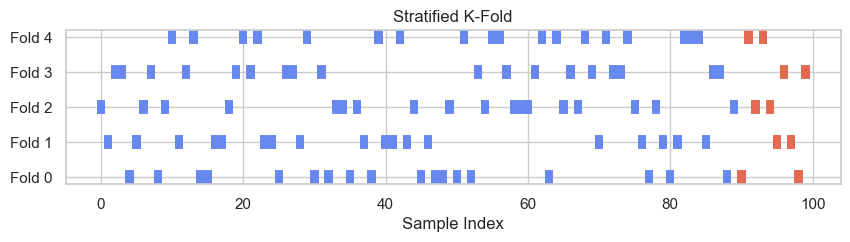

In [12]:
# Create heavily imbalanced dummy data
# Class 0: 90 samples, Class 1: 10 samples
X_imbalanced = np.random.randn(100, 2)
y_imbalanced = np.array([0]*90 + [1]*10)

def visualize_cv_splits(cv_obj, X, y, title):
    splits = list(cv_obj.split(X, y))
    
    fig, ax = plt.subplots(figsize=(10, 2))
    
    # We will plot the class of the validation set points across the folds
    for fold_idx, (train_idx, val_idx) in enumerate(splits):
        val_classes = y[val_idx]
        ax.scatter(val_idx, [fold_idx] * len(val_idx), 
                   c=val_classes, cmap='coolwarm', marker='_', lw=10, vmin=-0.2, vmax=1.2)
        
    ax.set_yticks(range(cv_obj.n_splits))
    ax.set_yticklabels([f'Fold {i}' for i in range(cv_obj.n_splits)])
    ax.set_xlabel('Sample Index')
    ax.set_title(title)
    plt.show()

print("Notice how Standard K-Fold might have folds with ZERO Class 1 samples (Red).")
visualize_cv_splits(KFold(n_splits=5, shuffle=True, random_state=42), X_imbalanced, y_imbalanced, 'Standard K-Fold (Random)')

print("Notice how Stratified K-Fold ensures exactly 2 Class 1 samples (Red) in EVERY fold.")
visualize_cv_splits(StratifiedKFold(n_splits=5, shuffle=True, random_state=42), X_imbalanced, y_imbalanced, 'Stratified K-Fold')


---
## 4. Information Theory (Self-Information & Entropy)

* **Self-Information (Surprise)**: $-\log_2(P(x))$
* **Entropy**: $-\sum P(x) \log_2(P(x))$


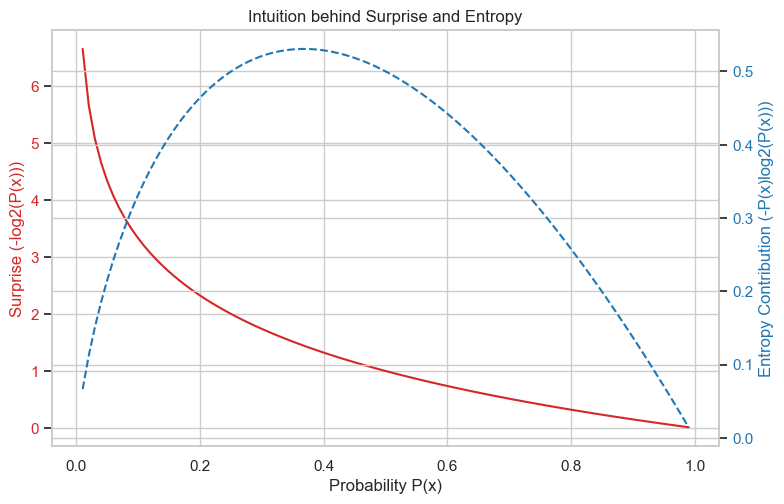

In [13]:
def manual_self_information(p):
    if p == 0:
        return 0 # Log 0 is undefined, but limit is 0 contribution to entropy
    return -np.log2(p)

def manual_entropy(probabilities):
    entropy = 0
    for p in probabilities:
        if p > 0:
            entropy += p * manual_self_information(p)
    return entropy

probabilities = np.linspace(0.01, 0.99, 100)
surprises = [manual_self_information(p) for p in probabilities]
entropy_contributions = [p * manual_self_information(p) for p in probabilities]

fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:red'
ax1.set_xlabel('Probability P(x)')
ax1.set_ylabel('Surprise (-log2(P(x)))', color=color)
ax1.plot(probabilities, surprises, color=color, label='Surprise')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Entropy Contribution (-P(x)log2(P(x)))', color=color)
ax2.plot(probabilities, entropy_contributions, color=color, linestyle='--', label='Entropy Contribution')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  
plt.title('Intuition behind Surprise and Entropy')
plt.show()


In [14]:
# Example of total entropy for a coin flip
p_heads_fair = 0.5
p_tails_fair = 0.5
print(f"Entropy of Fair Coin: {manual_entropy([p_heads_fair, p_tails_fair]):.2f} bits")

p_heads_biased = 0.99
p_tails_biased = 0.01
print(f"Entropy of Biased Coin (99/1): {manual_entropy([p_heads_biased, p_tails_biased]):.2f} bits")


Entropy of Fair Coin: 1.00 bits
Entropy of Biased Coin (99/1): 0.08 bits
